# Lab 4 — ROC Curve & AUC

**Day 03 · Classification & Model Interpretation · Cisco AI/ML Training**

---

## Goals

1. Build an **ROC curve** from predicted probabilities at many thresholds.
2. Compute **AUC** (area under the ROC curve).
3. Compare model performance to a **random classifier** (diagonal line).
4. Relate ROC to the threshold trade-offs from Lab 3.

> **Quick check:** AUC ≈ **0.63** · `roc_curve.png` saved · AUC **> 0.5**




## Why ROC when we already have precision/recall?

Lab 3 used a **single threshold** (0.5). ROC shows performance at **all** thresholds:

| Axis | Meaning |
|------|--------|
| **X — FPR** | False positive rate = FP / (FP + TN) |
| **Y — TPR** | True positive rate (recall) = TP / (TP + FN) |

**AUC** summarizes ranking quality: **0.5** = random, **1.0** = perfect.

---

## 1. Train model and get probability scores

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

LENDING_CLUB_CSV = GH_ROOT / "data" / "lending-club" / "lending_club_sample.csv"
DEFAULT_STATUSES = {"Charged Off", "Late (31-120 days)"}
NUMERIC_FEATURES = ["loan_amnt", "int_rate", "annual_inc", "dti", "installment"]
CATEGORICAL_FEATURES = ["grade", "term"]

from IPython.display import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

OUTPUT_DIR = GH_ROOT / "hands-on" / "03-classification-interpretation" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(LENDING_CLUB_CSV)
df["default"] = df["loan_status"].isin(DEFAULT_STATUSES).astype(int)

X, y = df[NUMERIC_FEATURES], df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_scores = model.predict_proba(X_test)[:, 1]

print(f"test scores: min={y_scores.min():.3f}, max={y_scores.max():.3f}")


test scores: min=0.184, max=0.783


`y_scores` = P(default=1) — the **ranking** signal ROC evaluates.

### 1b. Score distribution

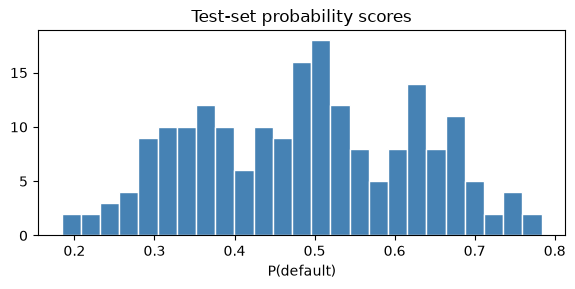

In [2]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(y_scores, bins=25, color="steelblue", edgecolor="white")
ax.set_xlabel("P(default)")
ax.set_title("Test-set probability scores")
plt.tight_layout()
plt.show()


---

## 2. Compute ROC curve points

In [3]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

print("Lab 4 — ROC and AUC")
print(f"ROC points: {len(fpr)}")
print(f"AUC (trapezoid): {roc_auc:.4f}")
print(f"AUC (sklearn shortcut): {roc_auc_score(y_test, y_scores):.4f}")
print(f"threshold at index 10: {thresholds[10]:.4f}")


Lab 4 — ROC and AUC
ROC points: 92
AUC (trapezoid): 0.6326
AUC (sklearn shortcut): 0.6326
threshold at index 10: 0.6669


Each point = one classification threshold. Left→right = lowering threshold.

### 2b. First few ROC points

In [4]:
roc_preview = pd.DataFrame({
    "fpr": fpr[:6].round(4),
    "tpr": tpr[:6].round(4),
    "threshold": thresholds[:6].round(4),
})
display(roc_preview)


,fpr,tpr,threshold
0,0.0000,0.0000,inf
1,0.0000,0.0103,0.7835
2,0.0000,0.0309,0.7585
3,0.0194,0.0309,0.7418
4,0.0194,0.0412,0.7392
5,0.0388,0.0412,0.7264


---

## 3. Plot ROC vs random baseline

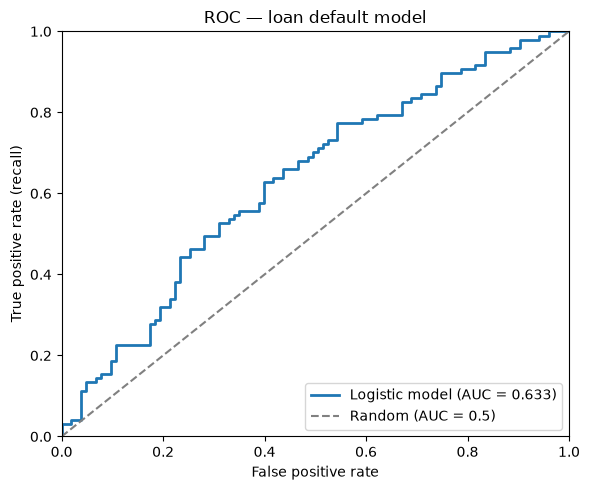

plot saved: roc_curve.png


In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, label=f"Logistic model (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUC = 0.5)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate (recall)")
ax.set_title("ROC — loan default model")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()

roc_plot = OUTPUT_DIR / "roc_curve.png"
fig.savefig(roc_plot, dpi=100, bbox_inches="tight")
plt.show()
print(f"plot saved: {roc_plot.name}")
assert roc_plot.is_file()


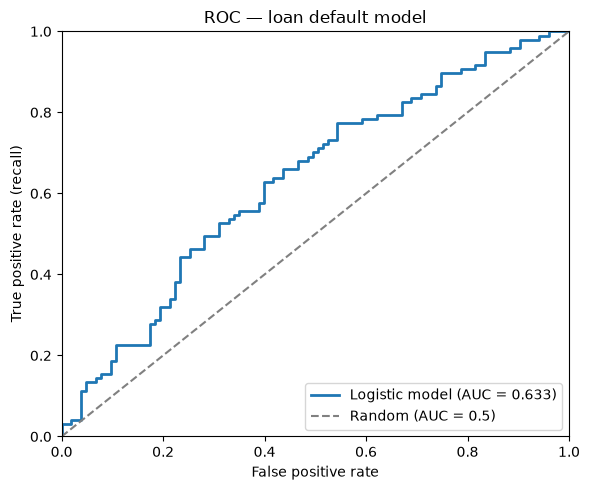

In [6]:
display(Image(filename=str(roc_plot)))


**Diagonal dashed line:** random classifier — AUC = 0.5. Curve **above** diagonal → model adds value.

---

## 4. Youden's J — best threshold on ROC

In [7]:
youden_j = tpr - fpr
best_idx = int(np.argmax(youden_j))
best_threshold = thresholds[best_idx]

print(f"Best Youden index at idx {best_idx}")
print(f"  threshold: {best_threshold:.4f}")
print(f"  TPR: {tpr[best_idx]:.4f}, FPR: {fpr[best_idx]:.4f}")
print(f"  J = {youden_j[best_idx]:.4f}")


Best Youden index at idx 44
  threshold: 0.4900
  TPR: 0.6289, FPR: 0.3981
  J = 0.2308


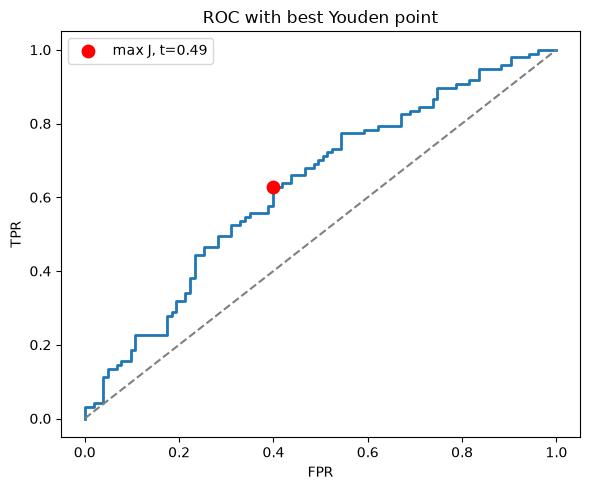

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2)
ax.scatter(fpr[best_idx], tpr[best_idx], color="red", s=80, zorder=5,
           label=f"max J, t={best_threshold:.2f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC with best Youden point")
ax.legend()
plt.tight_layout()
plt.show()


---

## 5. AUC interpretation for credit risk

| AUC range | Typical interpretation |
|-----------|------------------------|
| 0.5 | No discrimination |
| 0.6 – 0.7 | Acceptable for pilot models |
| 0.7 – 0.8 | Good |
| 0.8+ | Strong |

Our **~0.63** is reasonable for five numeric features — Lab 5 may lift slightly.

### 5b. Compare AUC to accuracy from Lab 3

In [9]:
from sklearn.metrics import accuracy_score
acc_05 = accuracy_score(y_test, (y_scores >= 0.5).astype(int))
print(f"accuracy @ 0.5: {acc_05:.4f}")
print(f"AUC:            {roc_auc:.4f}")
print("AUC measures ranking across all thresholds; accuracy uses one cutoff.")


accuracy @ 0.5: 0.5900
AUC:            0.6326
AUC measures ranking across all thresholds; accuracy uses one cutoff.


### 5c. Partial AUC — low FPR region

In [10]:
# Area where FPR < 0.3 (strict approval policy)
mask = fpr <= 0.3
if mask.sum() > 1:
    partial = auc(fpr[mask], tpr[mask])
    print(f"partial AUC (FPR≤0.3): {partial:.4f}")


partial AUC (FPR≤0.3): 0.0676


### 5d. TPR and FPR at threshold 0.5

In [11]:
from sklearn.metrics import confusion_matrix
pred_05 = (y_scores >= 0.5).astype(int)
tn5, fp5, fn5, tp5 = confusion_matrix(y_test, pred_05).ravel()
tpr_05 = tp5 / (tp5 + fn5)
fpr_05 = fp5 / (fp5 + tn5)
print(f"at 0.5: TPR={tpr_05:.4f}, FPR={fpr_05:.4f}")


at 0.5: TPR=0.5670, FPR=0.3883


---

## 6. Ranking quality intuition

In [12]:
# If we sort by score descending, defaults should appear earlier
rank_df = pd.DataFrame({"score": y_scores, "default": y_test.values}).sort_values("score", ascending=False)
rank_df["cum_defaults"] = rank_df["default"].cumsum()
rank_df["pct_reviewed"] = np.arange(1, len(rank_df) + 1) / len(rank_df)
print(rank_df.head(8)[["score", "default", "cum_defaults"]])


        score  default  cum_defaults
169  0.783499        1             1
52   0.771152        1             2
162  0.758533        1             3
32   0.745960        0             3
137  0.741846        0             3
109  0.739217        1             4
143  0.727341        0             4
176  0.726417        0             4


### 6b. Lift at top 20% scores

In [13]:
k = int(0.2 * len(y_test))
top_k = rank_df.head(k)
capture_rate = top_k["default"].sum() / y_test.sum()
print(f"top 20% scores capture {capture_rate:.1%} of all defaults")


top 20% scores capture 22.7% of all defaults


### 6c. Gini coefficient from AUC

In [14]:
gini = 2 * roc_auc - 1
print(f"Gini = 2*AUC - 1 = {gini:.4f}")


Gini = 2*AUC - 1 = 0.2651


---

## 7. Try it yourself

Use `roc_auc_score` on a shuffled copy of `y_scores` — what AUC do you expect?

In [15]:
rng = np.random.default_rng(42)
shuffled = rng.permutation(y_scores)
auc_random = roc_auc_score(y_test, shuffled)
print(f"AUC with shuffled scores: {auc_random:.4f} (expect ~0.5)")


AUC with shuffled scores: 0.4658 (expect ~0.5)


### 7b. Perfect ranker thought experiment

In [16]:
perfect = y_test.values.astype(float)  # 0/1 as scores — unrealistic but instructive
print(f"AUC if scores equaled labels: {roc_auc_score(y_test, perfect):.4f}")


AUC if scores equaled labels: 1.0000


### 7c. Save plot path check

In [17]:
print("Output directory:", OUTPUT_DIR)
print("roc_curve.png exists:", roc_plot.is_file())
print("file size (bytes):", roc_plot.stat().st_size)


Output directory: C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH\hands-on\03-classification-interpretation\output
roc_curve.png exists: True
file size (bytes): 29208


### 7d. ROC point at threshold 0.5 on curve

In [18]:
# Find closest threshold to 0.5 on ROC path
idx_05 = int(np.argmin(np.abs(thresholds - 0.5)))
print(f"closest ROC idx to 0.5: threshold={thresholds[idx_05]:.3f}, TPR={tpr[idx_05]:.3f}, FPR={fpr[idx_05]:.3f}")


closest ROC idx to 0.5: threshold=0.501, TPR=0.557, FPR=0.388


### 7e. Compare two models (numeric-only vs full — preview Lab 5)

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe_num = Pipeline([
    ("sc", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])
pipe_num.fit(X_train, y_train)
auc_num = roc_auc_score(y_test, pipe_num.predict_proba(X_test)[:, 1])
print(f"AUC numeric-only: {auc_num:.4f}")
print(f"AUC Lab 4 model:  {roc_auc:.4f}")


AUC numeric-only: 0.6323
AUC Lab 4 model:  0.6326


### 7f. FPR vs threshold

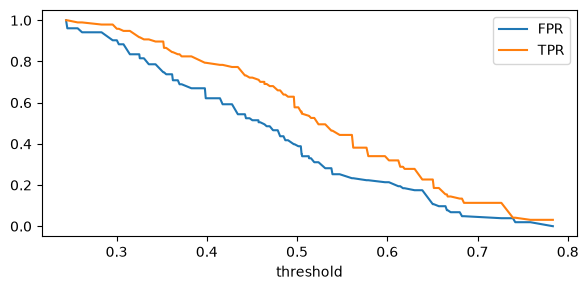

In [20]:
n = min(len(thresholds), len(fpr) - 1)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(thresholds[:n], fpr[1 : n + 1], label="FPR")
ax.plot(thresholds[:n], tpr[1 : n + 1], label="TPR")
ax.set_xlabel("threshold")
ax.legend()
plt.tight_layout()
plt.show()


### 7g. KS statistic (max TPR - FPR)

In [21]:
ks = np.max(tpr - fpr)
print(f"KS statistic: {ks:.4f} (same idea as Youden J)")


KS statistic: 0.2308 (same idea as Youden J)


### 7h. ROC for random scores

In [22]:
rng = np.random.default_rng(0)
rand_scores = rng.random(len(y_test))
fpr_r, tpr_r, _ = roc_curve(y_test, rand_scores)
print(f"random AUC: {auc(fpr_r, tpr_r):.4f}")


random AUC: 0.5254


### 7i. Count loans above score 0.6

In [23]:
print(f"test rows with P(default)>=0.6: {(y_scores >= 0.6).sum()}")


test rows with P(default)>=0.6: 51


### 7j. Median score by actual class

In [24]:
med0 = np.median(y_scores[y_test == 0])
med1 = np.median(y_scores[y_test == 1])
print(f"median score (non-default): {med0:.3f}")
print(f"median score (default):     {med1:.3f}")


median score (non-default): 0.457
median score (default):     0.518


### 7k. Re-save plot (idempotent)

In [25]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, lw=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title(f"ROC AUC={roc_auc:.3f}")
fig.savefig(roc_plot, dpi=100, bbox_inches="tight")
plt.close(fig)
print("plot refreshed:", roc_plot.name)


plot refreshed: roc_curve.png


---

## 8. Checkpoint summary

In [26]:
assert roc_auc > 0.5
assert abs(roc_auc - 0.6326) < 0.02
assert roc_plot.is_file()
print("Numbers match — you're good.")



Numbers match — you're good.


---

## Reflection questions

1. Can AUC be high while precision at 0.5 threshold is mediocre? Why?
2. When would you prefer optimizing recall over AUC?
3. How is ROC related to the threshold table in Lab 3?
4. What does the Youden point tell a credit analyst?
